##Preprocessing, Time Windowing and RFMT extraction



In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
import warnings
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from dateutil.relativedelta import relativedelta
warnings.filterwarnings('ignore')

In [ ]:
print("--- TAHAP 1: GATHERING & PRE-PROCESSING DATA ---")
# 1. Load Data (Sesuaikan nama file jika Anda menggunakan CSV)
file_path = 'online_retail_II.xlsx'
try:
    # Membaca kedua sheet dan menggabungkannya
    df_2009 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
    df_2010 = pd.read_excel(file_path, sheet_name='Year 2010-2011')
    df = pd.concat([df_2009, df_2010], ignore_index=True)
except:
    df = pd.read_csv('online_retail_II.csv')

print(f"Jumlah baris awal: {len(df)}")

--- TAHAP 1: GATHERING & PRE-PROCESSING DATA ---
Jumlah baris awal: 1067371


In [ ]:
# 2. Pre-processing
# a. Hapus baris dengan Customer ID kosong
df = df.dropna(subset=['Customer ID'])

# b. Hapus transaksi pembatalan (Invoice berawalan 'C')
df['Invoice'] = df['Invoice'].astype(str)
df = df[~df['Invoice'].str.startswith('C')]

# c. Hapus harga atau kuantitas negatif/nol
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# d. Hitung Total Pembelanjaan (Monetary per item)
df['TotalValue'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Jumlah baris setelah pre-processing (Data Bersih): {len(df)}")

Jumlah baris setelah pre-processing (Data Bersih): 805549


In [ ]:
# --- TAHAP 2: EKSTRAKSI & LABELING  ---
def extract_rfmt_and_label(data, start_obs_date, end_obs_date, end_perf_date):
    obs_data = data[(data['InvoiceDate'] >= start_obs_date) & (data['InvoiceDate'] < end_obs_date)]
    perf_data = data[(data['InvoiceDate'] >= end_obs_date) & (data['InvoiceDate'] < end_perf_date)]

    if obs_data.empty:
        return pd.DataFrame()

    # Ekstraksi RFM
    rfmt = obs_data.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda x: (end_obs_date - x.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('TotalValue', 'sum')
    ).reset_index()

    # Hitung Time (T) dan paksa menjadi tipe FLOAT agar XGBoost tidak error
    def calculate_time(customer_invoices):
        dates = customer_invoices.sort_values().unique()
        if len(dates) > 1:
            # Hitung rata-rata jarak waktu
            mean_diff = np.mean(np.diff(dates))
            # Bagi dengan 1 Hari untuk mengubahnya murni menjadi angka desimal (float)
            return float(mean_diff / np.timedelta64(1, 'D'))
        return 0.0

    time_feature = obs_data.groupby('Customer ID')['InvoiceDate'].apply(calculate_time).reset_index()
    time_feature.columns = ['Customer ID', 'Time']

    # Pastikan tipe datanya float
    time_feature['Time'] = pd.to_numeric(time_feature['Time'], errors='coerce').fillna(0.0)

    # Gabung RFM dan T
    rfmt = rfmt.merge(time_feature, on='Customer ID')

    # Labeling
    returning_customers = perf_data['Customer ID'].unique()
    rfmt['Churn_Label'] = np.where(rfmt['Customer ID'].isin(returning_customers), 0, 1)

    return rfmt

# Test Sliding Window

In [ ]:
# --- TAHAP 3: SLIDING WINDOW EVALUATION---
def run_sliding_window(data, window_months):
    print(f"\n{'='*60}")
    print(f"RUNNING SCENARIO: {window_months} MONTHS OBSERVATION WINDOW")
    print(f"{'='*60}")

    current_start_obs = data['InvoiceDate'].min().normalize()
    max_date = data['InvoiceDate'].max().normalize()

    metrics = {'precision': [], 'recall': [], 'f1': [], 'auc': []}
    slide_count = 1

    # Variabel untuk menyimpan data Train dari slide sebelumnya
    X_train_prev, y_train_prev = None, None

    final_model = None

    while True:
        current_end_obs = current_start_obs + relativedelta(months=window_months)
        current_end_perf = current_end_obs + pd.Timedelta(days=30)

        if current_end_perf > max_date:
            break

        # 1. Ekstrak data Slide saat ini
        df_slide = extract_rfmt_and_label(data, current_start_obs, current_end_obs, current_end_perf)

        if df_slide.empty or len(df_slide['Churn_Label'].unique()) < 2:
            current_start_obs += relativedelta(months=1)
            continue

        # 2. Definisikan Fitur (X) dan Target (y) untuk Slide ini
        X_current = df_slide[['Recency', 'Frequency', 'Monetary', 'Time']]
        y_current = df_slide['Churn_Label']

        # Jika kita SUDAH PUNYA data Train dari slide sebelumnya, kita Evaluasi!
        if X_train_prev is not None:
            # Hitung bobot Imbalance dari data TRAIN (Slide sebelumnya)
            spw = (y_train_prev == 0).sum() / (y_train_prev == 1).sum() if (y_train_prev == 1).sum() > 0 else 1.0

            # Bangun model menggunakan data TRAIN (Masa Lalu)
            model = XGBClassifier(random_state=42, scale_pos_weight=spw,
                      learning_rate=0.05, max_depth=6, eval_metric='logloss', importance_type='gain')
            model.fit(X_train_prev, y_train_prev)

            final_model = model

            # Prediksi ke data TEST (Slide Saat Ini / Masa Depan)
            y_pred = model.predict(X_current)
            y_prob = model.predict_proba(X_current)[:, 1]

            # Hitung Metrik
            prec = precision_score(y_current, y_pred, zero_division=0)
            rec = recall_score(y_current, y_pred, zero_division=0)
            f1 = f1_score(y_current, y_pred, zero_division=0)
            auc = roc_auc_score(y_current, y_prob)

            metrics['precision'].append(prec)
            metrics['recall'].append(rec)
            metrics['f1'].append(f1)
            metrics['auc'].append(auc)

            # PRINT METRIK UNTUK SLIDE INI
            print(f"Slide {slide_count:02d} (Tested on {current_start_obs.date()} to {current_end_obs.date()}) "
                  f"-> F1: {f1:.4f} | AUC: {auc:.4f} | Churn Rate: {(y_current.sum()/len(y_current))*100:.1f}%")
        else:
            # Ini adalah Slide Pertama, belum ada model yang bisa dievaluasi
            print(f"Slide {slide_count:02d} (Initial Training Window - No evaluation yet)")

        # Jadikan data saat ini sebagai data TRAIN untuk slide berikutnya (Slide berjalan maju)
        X_train_prev = X_current
        y_train_prev = y_current

        # Geser jendela maju 1 bulan
        current_start_obs += relativedelta(months=1)
        slide_count += 1

    # Print Rekapitulasi Rata-rata dan Standar Deviasi (Sesuai Permintaan Dosen)
    print(f"\n--- FINAL RECAP SCENARIO {window_months} MONTHS ---")
    print(f"Total Evaluated Slides: {len(metrics['f1'])}")
    if len(metrics['f1']) > 0:
        print(f"F1-Score  : {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
        print(f"AUC Score : {np.mean(metrics['auc']):.4f} ± {np.std(metrics['auc']):.4f}")
        print(f"Precision : {np.mean(metrics['precision']):.4f} ± {np.std(metrics['precision']):.4f}")
        print(f"Recall    : {np.mean(metrics['recall']):.4f} ± {np.std(metrics['recall']):.4f}\n")

    return final_model

In [ ]:
run_sliding_window(df, 3)


RUNNING SCENARIO: 3 MONTHS OBSERVATION WINDOW
Slide 01 (Initial Training Window - No evaluation yet)
Slide 02 (Tested on 2010-01-01 to 2010-04-01) -> F1: 0.7786 | AUC: 0.6745 | Churn Rate: 67.6%
Slide 03 (Tested on 2010-02-01 to 2010-05-01) -> F1: 0.7662 | AUC: 0.6903 | Churn Rate: 68.1%
Slide 04 (Tested on 2010-03-01 to 2010-06-01) -> F1: 0.7344 | AUC: 0.6890 | Churn Rate: 67.5%
Slide 05 (Tested on 2010-04-01 to 2010-07-01) -> F1: 0.7850 | AUC: 0.7052 | Churn Rate: 69.0%
Slide 06 (Tested on 2010-05-01 to 2010-08-01) -> F1: 0.7745 | AUC: 0.7040 | Churn Rate: 70.4%
Slide 07 (Tested on 2010-06-01 to 2010-09-01) -> F1: 0.7275 | AUC: 0.6697 | Churn Rate: 64.5%
Slide 08 (Tested on 2010-07-01 to 2010-10-01) -> F1: 0.7264 | AUC: 0.6561 | Churn Rate: 62.7%
Slide 09 (Tested on 2010-08-01 to 2010-11-01) -> F1: 0.6978 | AUC: 0.6490 | Churn Rate: 60.4%
Slide 10 (Tested on 2010-09-01 to 2010-12-01) -> F1: 0.7782 | AUC: 0.7196 | Churn Rate: 75.3%
Slide 11 (Tested on 2010-10-01 to 2011-01-01) -> F1:

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
run_sliding_window(df, 6)


RUNNING SCENARIO: 6 MONTHS OBSERVATION WINDOW
Slide 01 (Initial Training Window - No evaluation yet)
Slide 02 (Tested on 2010-01-01 to 2010-07-01) -> F1: 0.7930 | AUC: 0.7382 | Churn Rate: 73.7%
Slide 03 (Tested on 2010-02-01 to 2010-08-01) -> F1: 0.8033 | AUC: 0.7319 | Churn Rate: 75.1%
Slide 04 (Tested on 2010-03-01 to 2010-09-01) -> F1: 0.7919 | AUC: 0.7163 | Churn Rate: 70.4%
Slide 05 (Tested on 2010-04-01 to 2010-10-01) -> F1: 0.7545 | AUC: 0.6814 | Churn Rate: 66.5%
Slide 06 (Tested on 2010-05-01 to 2010-11-01) -> F1: 0.7378 | AUC: 0.6706 | Churn Rate: 63.7%
Slide 07 (Tested on 2010-06-01 to 2010-12-01) -> F1: 0.7861 | AUC: 0.7359 | Churn Rate: 78.0%
Slide 08 (Tested on 2010-07-01 to 2011-01-01) -> F1: 0.8516 | AUC: 0.7526 | Churn Rate: 82.3%
Slide 09 (Tested on 2010-08-01 to 2011-02-01) -> F1: 0.8448 | AUC: 0.7329 | Churn Rate: 81.1%
Slide 10 (Tested on 2010-09-01 to 2011-03-01) -> F1: 0.8352 | AUC: 0.7274 | Churn Rate: 79.2%
Slide 11 (Tested on 2010-10-01 to 2011-04-01) -> F1:

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
run_sliding_window(df, 12)


RUNNING SCENARIO: 12 MONTHS OBSERVATION WINDOW
Slide 01 (Initial Training Window - No evaluation yet)
Slide 02 (Tested on 2010-01-01 to 2011-01-01) -> F1: 0.8696 | AUC: 0.7895 | Churn Rate: 84.9%
Slide 03 (Tested on 2010-02-01 to 2011-02-01) -> F1: 0.8583 | AUC: 0.7654 | Churn Rate: 84.0%
Slide 04 (Tested on 2010-03-01 to 2011-03-01) -> F1: 0.8418 | AUC: 0.7691 | Churn Rate: 82.3%
Slide 05 (Tested on 2010-04-01 to 2011-04-01) -> F1: 0.8423 | AUC: 0.7505 | Churn Rate: 82.9%
Slide 06 (Tested on 2010-05-01 to 2011-05-01) -> F1: 0.8479 | AUC: 0.7667 | Churn Rate: 79.2%
Slide 07 (Tested on 2010-06-01 to 2011-06-01) -> F1: 0.8358 | AUC: 0.7804 | Churn Rate: 80.0%
Slide 08 (Tested on 2010-07-01 to 2011-07-01) -> F1: 0.8169 | AUC: 0.7784 | Churn Rate: 81.3%
Slide 09 (Tested on 2010-08-01 to 2011-08-01) -> F1: 0.8452 | AUC: 0.8001 | Churn Rate: 81.6%
Slide 10 (Tested on 2010-09-01 to 2011-09-01) -> F1: 0.8251 | AUC: 0.7644 | Churn Rate: 75.8%
Slide 11 (Tested on 2010-10-01 to 2011-10-01) -> F1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Extracting importance for 3 Months...
Extracting importance for 6 Months...
Extracting importance for 12 Months...


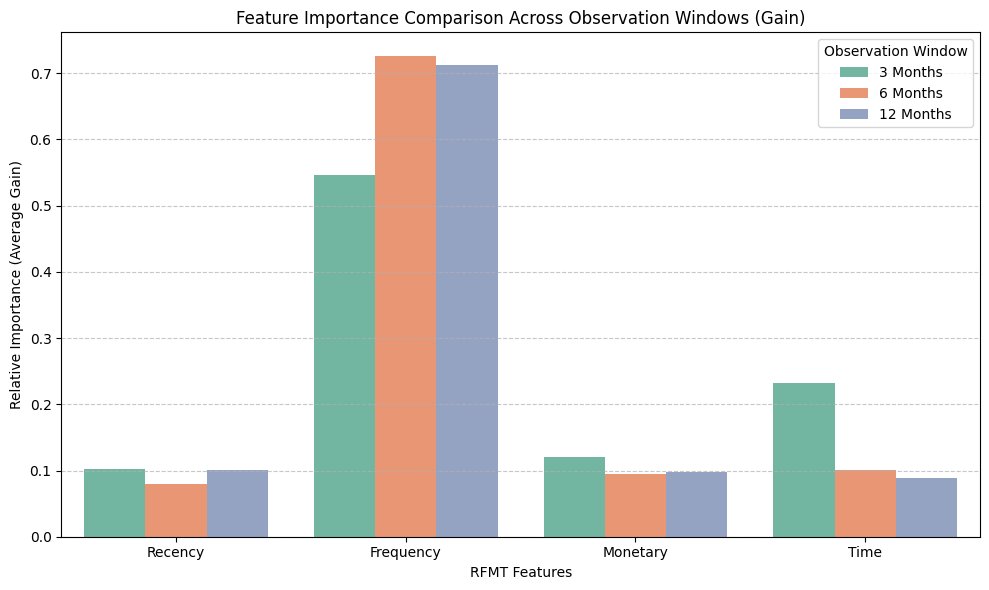

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from dateutil.relativedelta import relativedelta

# Pastikan fungsi extract_rfmt_and_label yang versi fix sudah di-run sebelumnya ya!

def get_avg_feature_importance(data, window_months):
    current_start_obs = data['InvoiceDate'].min().normalize()
    max_date = data['InvoiceDate'].max().normalize()

    feature_importances_list = []
    feature_names = ['Recency', 'Frequency', 'Monetary', 'Time']
    X_train_prev, y_train_prev = None, None

    while True:
        current_end_obs = current_start_obs + relativedelta(months=window_months)
        current_end_perf = current_end_obs + pd.Timedelta(days=30)

        if current_end_perf > max_date:
            break

        df_slide = extract_rfmt_and_label(data, current_start_obs, current_end_obs, current_end_perf)

        if not df_slide.empty and len(df_slide['Churn_Label'].unique()) >= 2:
            X_current = df_slide[feature_names]
            y_current = df_slide['Churn_Label']

            if X_train_prev is not None:
                spw = (y_train_prev == 0).sum() / (y_train_prev == 1).sum() if (y_train_prev == 1).sum() > 0 else 1.0
                model = XGBClassifier(random_state=42, scale_pos_weight=spw,
                      learning_rate=0.05, max_depth=6, eval_metric='logloss', importance_type='gain')
                model.fit(X_train_prev, y_train_prev)
                feature_importances_list.append(model.feature_importances_)

            X_train_prev = X_current
            y_train_prev = y_current

        current_start_obs += relativedelta(months=1)

    # Hitung rata-rata
    avg_importances = np.mean(np.array(feature_importances_list), axis=0)

    # Kembalikan sebagai DataFrame
    return pd.DataFrame({
        'Feature': feature_names,
        'Importance': avg_importances,
        'Scenario': f'{window_months} Months'
    })

print("Extracting importance for 3 Months...")
df_imp_3 = get_avg_feature_importance(df, 3)

print("Extracting importance for 6 Months...")
df_imp_6 = get_avg_feature_importance(df, 6)

print("Extracting importance for 12 Months...")
df_imp_12 = get_avg_feature_importance(df, 12)

# --- MENGGABUNGKAN DATA ---
df_all_importance = pd.concat([df_imp_3, df_imp_6, df_imp_12], ignore_index=True)

# --- PLOTTING GRAFIK GABUNGAN ---
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Feature',
    y='Importance',
    hue='Scenario',
    data=df_all_importance,
    palette='Set2'
)

plt.title('Feature Importance Comparison Across Observation Windows (Gain)')
plt.xlabel('RFMT Features')
plt.ylabel('Relative Importance (Average Gain)')
plt.legend(title='Observation Window')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Simpan untuk di-insert ke paper
plt.savefig('combined_feature_importance.png', dpi=300)
plt.show()

In [ ]:
import pickle

model_3m = run_sliding_window(df, 3)
model_6m = run_sliding_window(df, 6)
model_12m = run_sliding_window(df, 12)

# 2. Save masing-masing model ke file .pkl
with open('model_3_months.pkl', 'wb') as f:
    pickle.dump(model_3m, f)

with open('model_6_months.pkl', 'wb') as f:
    pickle.dump(model_6m, f)

with open('model_12_months.pkl', 'wb') as f:
    pickle.dump(model_12m, f)

print("Semua model berhasil diexport!")


RUNNING SCENARIO: 3 MONTHS OBSERVATION WINDOW
Slide 01 (Initial Training Window - No evaluation yet)
Slide 02 (Tested on 2010-01-01 to 2010-04-01) -> F1: 0.7786 | AUC: 0.6745 | Churn Rate: 67.6%
Slide 03 (Tested on 2010-02-01 to 2010-05-01) -> F1: 0.7662 | AUC: 0.6903 | Churn Rate: 68.1%
Slide 04 (Tested on 2010-03-01 to 2010-06-01) -> F1: 0.7344 | AUC: 0.6890 | Churn Rate: 67.5%
Slide 05 (Tested on 2010-04-01 to 2010-07-01) -> F1: 0.7850 | AUC: 0.7052 | Churn Rate: 69.0%
Slide 06 (Tested on 2010-05-01 to 2010-08-01) -> F1: 0.7745 | AUC: 0.7040 | Churn Rate: 70.4%
Slide 07 (Tested on 2010-06-01 to 2010-09-01) -> F1: 0.7275 | AUC: 0.6697 | Churn Rate: 64.5%
Slide 08 (Tested on 2010-07-01 to 2010-10-01) -> F1: 0.7264 | AUC: 0.6561 | Churn Rate: 62.7%
Slide 09 (Tested on 2010-08-01 to 2010-11-01) -> F1: 0.6978 | AUC: 0.6490 | Churn Rate: 60.4%
Slide 10 (Tested on 2010-09-01 to 2010-12-01) -> F1: 0.7782 | AUC: 0.7196 | Churn Rate: 75.3%
Slide 11 (Tested on 2010-10-01 to 2011-01-01) -> F1: